In [1]:
import pandas as pd
# !pip install openskills anthropic pandas

In [3]:
# !pip install anthropic pandas

In [ ]:
import anthropic
import pandas as pd



# 1. Carga tu dataset del Caso 2
df = pd.read_csv('./train.csv')

# 2. Preparamos un resumen para no gastar tokens de más
resumen_datos = f"""
Estructura del Dataset:
{df.info()}

Primeras 5 filas:
{df.head().to_csv()}

Estadísticas básicas:
{df.describe().to_csv()}
"""

# 3. El "Skill" (Instrucciones del prompt Grade A)
prompt_eda = f"""
Eres un experto en Data Science. Realiza un Análisis Exploratorio de Datos (EDA) de Grado A.
Debes identificar: 
1. Calidad de datos (nulos, tipos incorrectos).
2. Outliers y distribuciones clave.
3. Sugerencias de visualizaciones críticas.
4. Posibles correlaciones para el modelo predictivo.

Aquí están los datos:
{resumen_datos}
"""

# 4. Llamamos a Claude
message = client.messages.create(
    model="claude-3-5-sonnet-20240620", # O la versión que prefieras
    max_tokens=2000,
    messages=[{"role": "user", "content": prompt_eda}]
)

print(message.content[0].text)

NameError: name 'os' is not defined

In [ ]:
import pandas as pd
from openskills import load_skill

# 1. Carga tus datos (ejemplo con un CSV de tu carpeta del Caso 2)
df = pd.read_csv('./train.csv')
# 2. Cargar el skill específico de EDA que instalaste
# Nota: La ruta depende de cómo se registró en tu AGENTS.md
eda_skill = load_skill("eda-grade-a") 

# 3. Ejecutar el análisis
# Le pasamos una muestra de los datos (o el info) para que no sature el contexto
contexto_datos = df.head(10).to_markdown()
resultado = eda_skill.run(input_data=contexto_datos)

print(resultado)

ModuleNotFoundError: No module named 'openskills'

In [ ]:
df.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  object 
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 17  State          14993 non-null  int64  
 18  Rescue

In [ ]:
df.describe()

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000
mean,1.457614,10.452078,265.272594,74.009738,1.776162,2.234176,3.222837,1.882012,1.862002,1.467485,1.731208,1.558727,1.914227,1.036617,1.576069,21.259988,41346.028347,0.056760,3.889215,2.516441
std,0.498217,18.155790,60.056818,123.011575,0.681592,1.745225,2.742562,2.984086,0.547959,0.599070,0.667649,0.695817,0.566172,0.199535,1.472477,78.414548,32.444153,0.346185,3.487810,1.177265
min,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,41324.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,265.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,2.000000,2.000000
50%,1.000000,3.000000,266.000000,0.000000,2.000000,2.000000,2.000000,0.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,3.000000,2.000000
75%,2.000000,12.000000,307.000000,179.000000,2.000000,3.000000,6.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,41401.000000,0.000000,5.000000,4.000000
max,2.000000,255.000000,307.000000,307.000000,3.000000,7.000000,7.000000,7.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,20.000000,3000.000000,41415.000000,8.000000,30.000000,4.000000


Missing Values (%):
Name           8.437271
Description    0.086707
dtype: float64


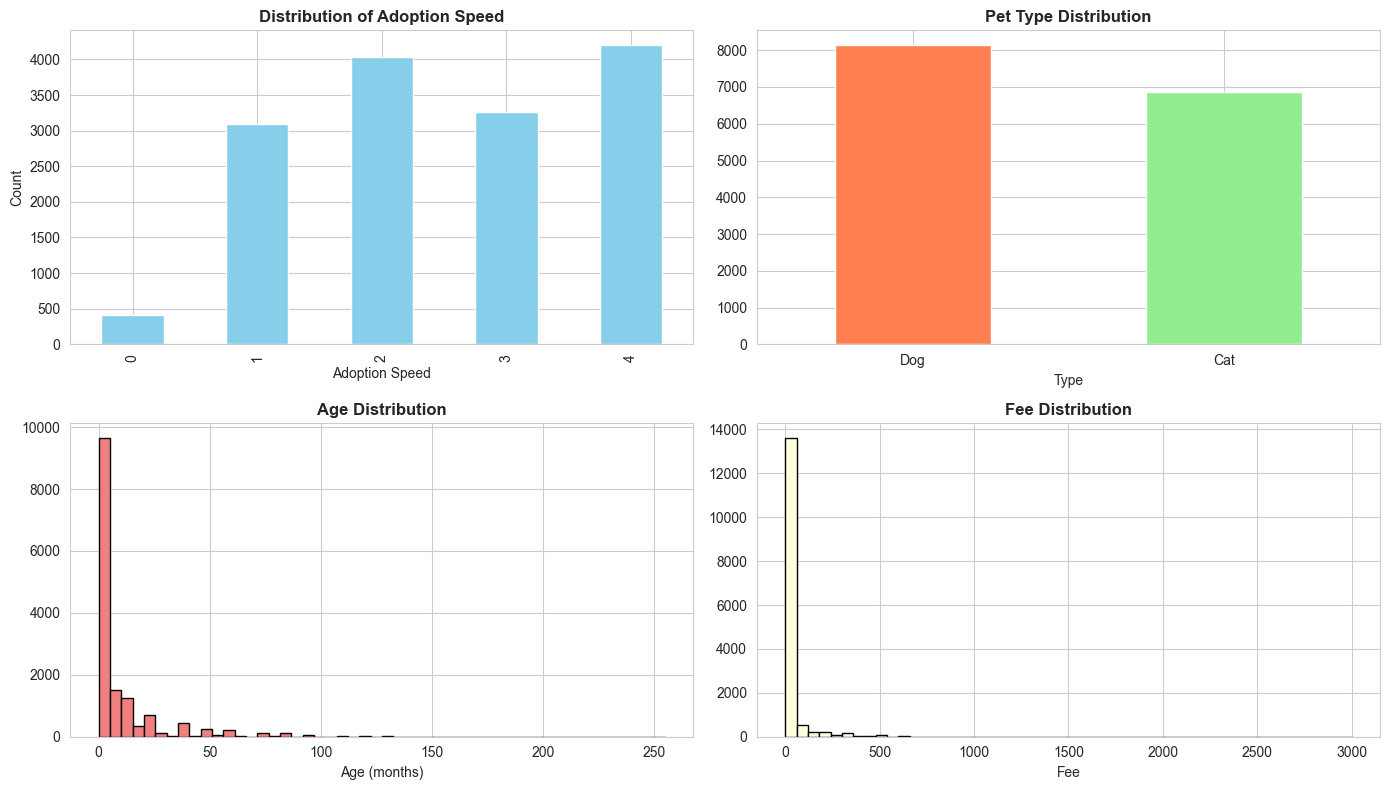


Feature Correlation with AdoptionSpeed:
AdoptionSpeed    1.000000
Breed1           0.107834
Age              0.100510
Quantity         0.062931
Gender           0.057622
MaturitySize     0.045653
Health           0.029382
State            0.013119
VideoAmt        -0.000571
Fee             -0.004017
Color3          -0.007014
Dewormed        -0.013210
Breed2          -0.018642
PhotoAmt        -0.023233
Color2          -0.038579
Color1          -0.044192
Vaccinated      -0.059043
Sterilized      -0.083447
Type            -0.091240
FurLength       -0.091337
Name: AdoptionSpeed, dtype: float64


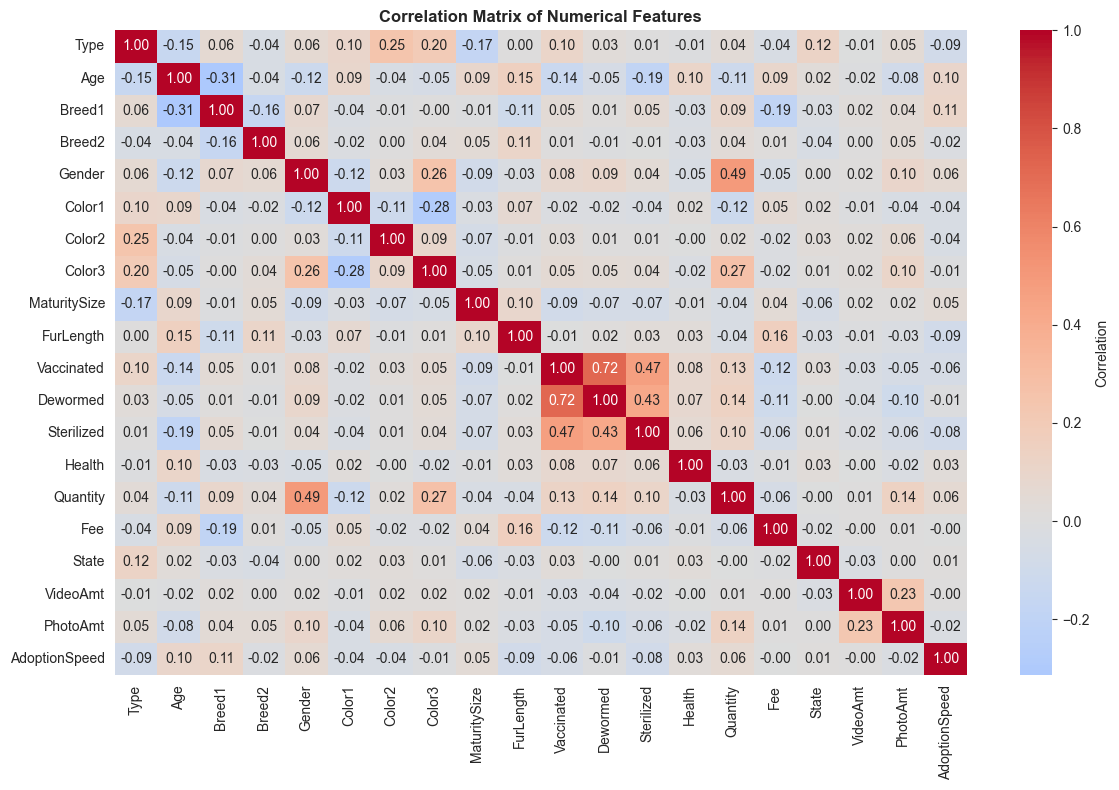

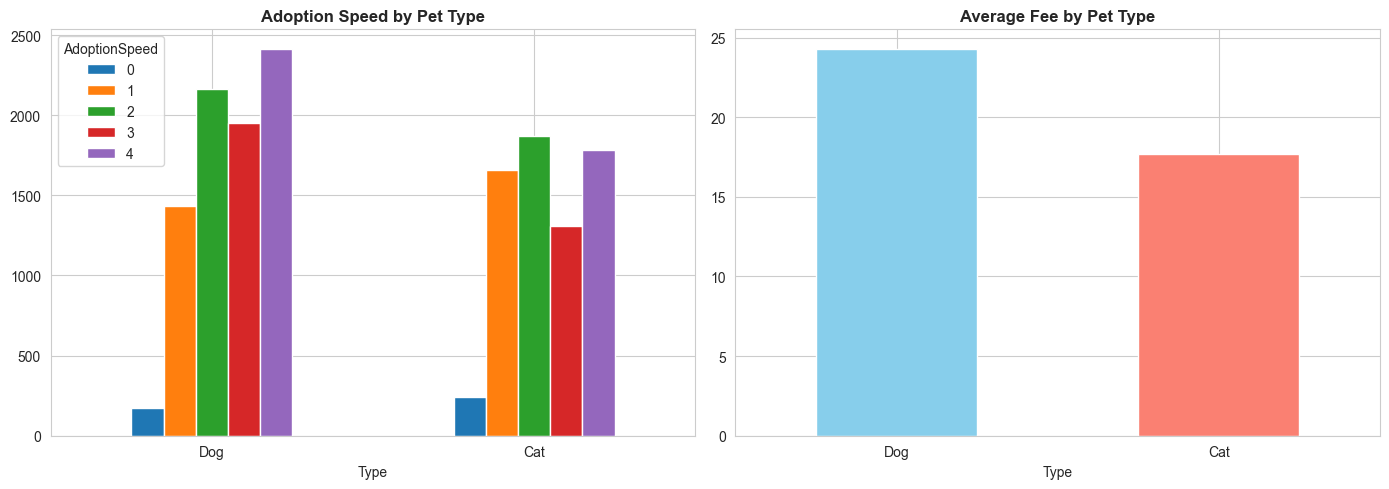


Categorical Features Summary:
Gender unique values: 3
Health unique values: 3
State unique values: 14
MaturitySize unique values: 4

Key Statistics:
Total pets: 14993
Average age: 10.45 months
Average fee: $21.26
Photos available: 14652 pets (97.7%)
Videos available: 574 pets (3.8%)


In [ ]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# 1. Missing values analysis
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Missing Values (%):")
print(missing_pct[missing_pct > 0])

# 2. Adoption Speed Distribution (Target Variable)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df['AdoptionSpeed'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Adoption Speed', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Adoption Speed')
axes[0, 0].set_ylabel('Count')

# 3. Type Distribution (Cat vs Dog)
df['Type'].value_counts().plot(kind='bar', ax=axes[0, 1], color=['coral', 'lightgreen'])
axes[0, 1].set_title('Pet Type Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(['Dog' if x == 1 else 'Cat' for x in df['Type'].value_counts().index], rotation=0)

# 4. Age Distribution
df['Age'].hist(bins=50, ax=axes[1, 0], color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age (months)')

# 5. Fee Distribution
df['Fee'].hist(bins=50, ax=axes[1, 1], color='lightyellow', edgecolor='black')
axes[1, 1].set_title('Fee Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Fee')

plt.tight_layout()
plt.show()

# 6. Correlation with AdoptionSpeed
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['AdoptionSpeed'].sort_values(ascending=False)
print("\nFeature Correlation with AdoptionSpeed:")
print(correlations)

# 7. Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Numerical Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 8. Adoption Speed by Pet Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.crosstab(df['Type'], df['AdoptionSpeed']).plot(kind='bar', ax=axes[0])
axes[0].set_title('Adoption Speed by Pet Type', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Dog', 'Cat'], rotation=0)

df.groupby('Type')['Fee'].mean().plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'])
axes[1].set_title('Average Fee by Pet Type', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Dog', 'Cat'], rotation=0)
plt.tight_layout()
plt.show()

# 9. Categorical features summary
print("\nCategorical Features Summary:")
print(f"Gender unique values: {df['Gender'].nunique()}")
print(f"Health unique values: {df['Health'].nunique()}")
print(f"State unique values: {df['State'].nunique()}")
print(f"MaturitySize unique values: {df['MaturitySize'].nunique()}")

# 10. Key Statistics
print("\nKey Statistics:")
print(f"Total pets: {len(df)}")
print(f"Average age: {df['Age'].mean():.2f} months")
print(f"Average fee: ${df['Fee'].mean():.2f}")
print(f"Photos available: {(df['PhotoAmt'] > 0).sum()} pets ({(df['PhotoAmt'] > 0).sum()/len(df)*100:.1f}%)")
print(f"Videos available: {(df['VideoAmt'] > 0).sum()} pets ({(df['VideoAmt'] > 0).sum()/len(df)*100:.1f}%)")

COMPREHENSIVE EXPLORATORY DATA ANALYSIS

1. DATASET OVERVIEW
Shape: (14993, 24)
Memory Usage: 2.75 MB

2. DATA TYPES
Type               int64
Name              object
Age                int64
Breed1             int64
Breed2             int64
Gender             int64
Color1             int64
Color2             int64
Color3             int64
MaturitySize       int64
FurLength          int64
Vaccinated         int64
Dewormed           int64
Sterilized         int64
Health             int64
Quantity           int64
Fee                int64
State              int64
RescuerID         object
VideoAmt           int64
Description       object
PetID             object
PhotoAmt         float64
AdoptionSpeed      int64
dtype: object

3. DUPLICATE ROWS: 0

4. STATISTICAL SUMMARY
                 count          mean         std      min      25%      50%  \
Type           14993.0      1.457614    0.498217      1.0      1.0      1.0   
Age            14993.0     10.452078   18.155790      0.0      2.

C:\Users\lucki\AppData\Local\Temp\ipykernel_15136\4288566092.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='AdoptionSpeed', ax=axes[0, 1], palette='Set2')


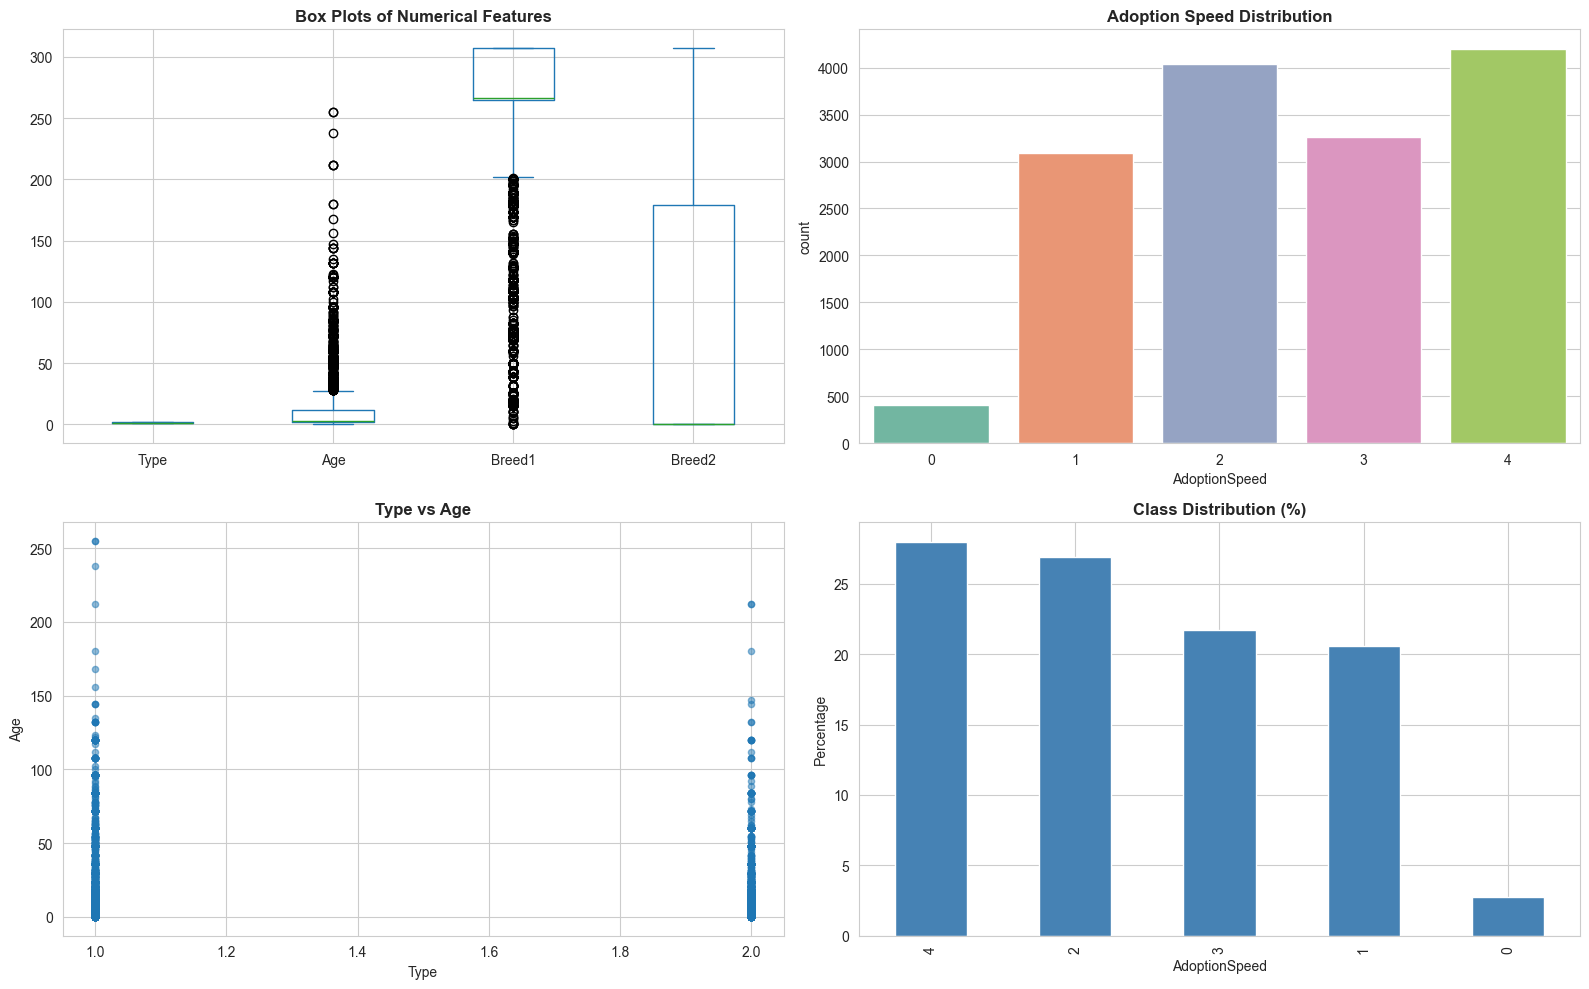


EDA COMPLETE


In [ ]:
# Comprehensive EDA Report
print("="*60)
print("COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("="*60)

# 1. Dataset Overview
print("\n1. DATASET OVERVIEW")
print(f"Shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

# 2. Data Types
print("\n2. DATA TYPES")
print(df.dtypes)

# 3. Duplicate Rows
print(f"\n3. DUPLICATE ROWS: {df.duplicated().sum()}")

# 4. Statistical Summary
print("\n4. STATISTICAL SUMMARY")
print(df.describe().T)

# 5. Skewness and Kurtosis
print("\n5. SKEWNESS & KURTOSIS")
numeric_features = df.select_dtypes(include=[np.number]).columns
for col in numeric_features:
    print(f"{col}: Skewness = {df[col].skew():.3f}, Kurtosis = {df[col].kurtosis():.3f}")

# 6. Outlier Detection (IQR Method)
print("\n6. OUTLIER DETECTION (IQR Method)")
for col in numeric_features:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

# 7. Categorical Features Distribution
print("\n7. CATEGORICAL FEATURES")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

# 8. Missing Values Analysis
print("\n8. MISSING VALUES ANALYSIS")
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Missing_Count'] > 0])

# 9. Advanced Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Box plots for numerical features
df[numeric_features[:4]].plot(kind='box', ax=axes[0, 0])
axes[0, 0].set_title('Box Plots of Numerical Features', fontweight='bold')

# Distribution of categorical target
if 'AdoptionSpeed' in df.columns:
    sns.countplot(data=df, x='AdoptionSpeed', ax=axes[0, 1], palette='Set2')
    axes[0, 1].set_title('Adoption Speed Distribution', fontweight='bold')

# Pair relationships (sample)
df[numeric_features[:3]].plot(kind='scatter', x=numeric_features[0], y=numeric_features[1], ax=axes[1, 0], alpha=0.5)
axes[1, 0].set_title(f'{numeric_features[0]} vs {numeric_features[1]}', fontweight='bold')

# Class imbalance
if 'AdoptionSpeed' in df.columns:
    class_dist = df['AdoptionSpeed'].value_counts() / len(df) * 100
    class_dist.plot(kind='bar', ax=axes[1, 1], color='steelblue')
    axes[1, 1].set_title('Class Distribution (%)', fontweight='bold')
    axes[1, 1].set_ylabel('Percentage')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EDA COMPLETE")
print("="*60)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Data Preprocessing and Feature Engineering

# 1. Handle Missing Values
print("="*60)
print("MISSING VALUES HANDLING")
print("="*60)

# Fill missing 'Name' with 'Unknown'
df['Name'].fillna('Unknown', inplace=True)

# Fill missing 'Description' with empty string
df['Description'].fillna('', inplace=True)

print(f"Missing values after imputation:\n{df.isnull().sum().sum()}")

# 2. Convert Categorical Variables to Numeric (if needed)
print("\n" + "="*60)
print("CATEGORICAL ENCODING")
print("="*60)

# RescuerID is already object type but can be label encoded for modeling

le_rescuer = LabelEncoder()
df['RescuerID_encoded'] = le_rescuer.fit_transform(df['RescuerID'])

le_petid = LabelEncoder()
df['PetID_encoded'] = le_petid.fit_transform(df['PetID'])

print(f"RescuerID unique values: {df['RescuerID'].nunique()}")
print(f"PetID unique values: {df['PetID'].nunique()}")

# 3. Standardization/Normalization
print("\n" + "="*60)
print("FEATURE SCALING")
print("="*60)


# Select numeric columns for scaling (excluding target and IDs)
scaling_cols = ['Age', 'Fee', 'PhotoAmt', 'VideoAmt', 'Quantity']

scaler = StandardScaler()
df[f'{scaling_cols}_scaled'] = scaler.fit_transform(df[scaling_cols])

print(f"Scaled features: {scaling_cols}")
print(f"Scaling applied: StandardScaler")

# 4. Summary of preprocessing
print("\n" + "="*60)
print("PREPROCESSING SUMMARY")
print("="*60)
print(f"Dataset shape after preprocessing: {df.shape}")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"New encoded features: RescuerID_encoded, PetID_encoded")
print(f"New scaled features: {scaling_cols}_scaled")

MISSING VALUES HANDLING
Missing values after imputation:
0

CATEGORICAL ENCODING
RescuerID unique values: 5595
PetID unique values: 14993

FEATURE SCALING


C:\Users\lucki\AppData\Local\Temp\ipykernel_15136\3721871602.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Name'].fillna('Unknown', inplace=True)
C:\Users\lucki\AppData\Local\Temp\ipykernel_15136\3721871602.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

ValueError: Expected a 1D array, got an array with shape (14993, 5)

In [ ]:
!pip install pptx

ERROR: Could not find a version that satisfies the requirement pptx (from versions: none)
ERROR: No matching distribution found for pptx

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\lucki\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
import io
import seaborn as sns

import matplotlib.pyplot as plt

# Create presentation
prs = Presentation()
prs.slide_width = Inches(10)
prs.slide_height = Inches(7.5)

# Slide 1: Title Slide
slide = prs.slides.add_slide(prs.slide_layouts[6])  # Blank layout
background = slide.background
fill = background.fill
fill.solid()
fill.fore_color.rgb = RGBColor(31, 78, 121)

title_box = slide.shapes.add_textbox(Inches(1), Inches(2.5), Inches(8), Inches(1.5))
title_frame = title_box.text_frame
title_frame.text = "Pet Adoption Analysis"
title_frame.paragraphs[0].font.size = Pt(54)
title_frame.paragraphs[0].font.bold = True
title_frame.paragraphs[0].font.color.rgb = RGBColor(255, 255, 255)
title_frame.paragraphs[0].alignment = PP_ALIGN.CENTER

subtitle_box = slide.shapes.add_textbox(Inches(1), Inches(4.2), Inches(8), Inches(1))
subtitle_frame = subtitle_box.text_frame
subtitle_frame.text = "Exploratory Data Analysis Report"
subtitle_frame.paragraphs[0].font.size = Pt(28)
subtitle_frame.paragraphs[0].font.color.rgb = RGBColor(200, 200, 200)
subtitle_frame.paragraphs[0].alignment = PP_ALIGN.CENTER

# Slide 2: Dataset Overview
slide = prs.slides.add_slide(prs.slide_layouts[1])
title = slide.shapes.title
title.text = "Dataset Overview"
title.text_frame.paragraphs[0].font.size = Pt(44)

content = slide.placeholders[1].text_frame
content.text = f"Total Records: {len(df):,}\nTotal Features: {df.shape[1]}\nMemory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB\nMissing Values: {df.isnull().sum().sum()}\nDuplicate Rows: {df.duplicated().sum()}"
for paragraph in content.paragraphs:
    paragraph.font.size = Pt(24)
    paragraph.space_before = Pt(12)

# Slide 3: Data Types Distribution
slide = prs.slides.add_slide(prs.slide_layouts[1])
title = slide.shapes.title
title.text = "Data Types Distribution"

left = Inches(1)
top = Inches(2)
fig, ax = plt.subplots(figsize=(8, 4))
df.dtypes.value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Data Types in Dataset', fontsize=12, fontweight='bold')
ax.set_xlabel('Data Type')
ax.set_ylabel('Count')
plt.tight_layout()

img_stream = io.BytesIO()
fig.savefig(img_stream, format='png', dpi=150, bbox_inches='tight')
img_stream.seek(0)
plt.close(fig)
slide.shapes.add_picture(img_stream, left, top, width=Inches(8))

# Slide 4: Missing Values
slide = prs.slides.add_slide(prs.slide_layouts[1])
title = slide.shapes.title
title.text = "Missing Values Analysis"

missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

content = slide.placeholders[1].text_frame
content.text = "Columns with Missing Values:\n"
for idx, (col, pct) in enumerate(missing.items()):
    if idx < 10:
        content.add_paragraph(f"{col}: {pct:.2f}%")
        content.paragraphs[-1].level = 1
        content.paragraphs[-1].font.size = Pt(18)

# Slide 5: Adoption Speed Distribution
slide = prs.slides.add_slide(prs.slide_layouts[6])
left = Inches(0.5)
top = Inches(0.5)

fig, ax = plt.subplots(figsize=(10, 7))
df['AdoptionSpeed'].value_counts().sort_index().plot(kind='bar', ax=ax, color='coral')
ax.set_title('Adoption Speed Distribution (Target Variable)', fontsize=14, fontweight='bold')
ax.set_xlabel('Adoption Speed')
ax.set_ylabel('Count')
plt.tight_layout()

img_stream = io.BytesIO()
fig.savefig(img_stream, format='png', dpi=150, bbox_inches='tight')
img_stream.seek(0)
plt.close(fig)
slide.shapes.add_picture(img_stream, left, top, width=Inches(9.5), height=Inches(7))

# Slide 6: Pet Type Distribution
slide = prs.slides.add_slide(prs.slide_layouts[6])
left = Inches(0.5)
top = Inches(0.5)

fig, ax = plt.subplots(figsize=(10, 7))
type_counts = df['Type'].value_counts()
type_labels = ['Dog' if x == 1 else 'Cat' for x in type_counts.index]
type_counts.plot(kind='bar', ax=ax, color=['skyblue', 'salmon'])
ax.set_xticklabels(type_labels, rotation=0)
ax.set_title('Pet Type Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()

img_stream = io.BytesIO()
fig.savefig(img_stream, format='png', dpi=150, bbox_inches='tight')
img_stream.seek(0)
plt.close(fig)
slide.shapes.add_picture(img_stream, left, top, width=Inches(9.5), height=Inches(7))

# Slide 7: Correlation Heatmap
slide = prs.slides.add_slide(prs.slide_layouts[6])
left = Inches(0.5)
top = Inches(0.5)

numeric_cols = df.select_dtypes(include=[np.number]).columns[:10]
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()

img_stream = io.BytesIO()
fig.savefig(img_stream, format='png', dpi=150, bbox_inches='tight')
img_stream.seek(0)
plt.close(fig)
slide.shapes.add_picture(img_stream, left, top, width=Inches(9.5), height=Inches(7))

# Slide 8: Key Statistics
slide = prs.slides.add_slide(prs.slide_layouts[1])
title = slide.shapes.title
title.text = "Key Statistics"

content = slide.placeholders[1].text_frame
content.text = f"Average Age: {df['Age'].mean():.2f} months\n"
for line in [
    f"Average Fee: ${df['Fee'].mean():.2f}",
    f"Pets with Photos: {(df['PhotoAmt'] > 0).sum()} ({(df['PhotoAmt'] > 0).sum()/len(df)*100:.1f}%)",
    f"Pets with Videos: {(df['VideoAmt'] > 0).sum()} ({(df['VideoAmt'] > 0).sum()/len(df)*100:.1f}%)",
    f"Unique Breeds: {df['Breed1'].nunique()}",
    f"Unique States: {df['State'].nunique()}"
]:
    content.add_paragraph(line)
    content.paragraphs[-1].level = 0
    content.paragraphs[-1].font.size = Pt(22)
    content.paragraphs[-1].space_before = Pt(12)

# Save presentation
prs.save('Pet_Adoption_EDA_Report.pptx')
print("✓ Presentación creada: Pet_Adoption_EDA_Report.pptx")

TypeError: TextFrame.add_paragraph() takes 1 positional argument but 2 were given

In [9]:
import subprocess
import sys
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor

# Instalación de la librería si no está presente
try:
    from pptx import Presentation
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-pptx"])
    from pptx import Presentation

# --- INICIO DE LA CREACIÓN DE LA PRESENTACIÓN ---
prs = Presentation()
prs.slide_width = Inches(10)
prs.slide_height = Inches(7.5)

# Slide 1: Title Slide (Layout 6 - Blank)
slide = prs.slides.add_slide(prs.slide_layouts[6])
background = slide.background
fill = background.fill
fill.solid()
fill.fore_color.rgb = RGBColor(31, 78, 121)

title_box = slide.shapes.add_textbox(Inches(1), Inches(2.5), Inches(8), Inches(1.5))
title_frame = title_box.text_frame
title_frame.text = "Pet Adoption Analysis"
title_frame.paragraphs[0].font.size = Pt(54)
title_frame.paragraphs[0].font.bold = True
title_frame.paragraphs[0].font.color.rgb = RGBColor(255, 255, 255)
title_frame.paragraphs[0].alignment = PP_ALIGN.CENTER

subtitle_box = slide.shapes.add_textbox(Inches(1), Inches(4.2), Inches(8), Inches(1))
subtitle_frame = subtitle_box.text_frame
subtitle_frame.text = "Exploratory Data Analysis Report"
subtitle_frame.paragraphs[0].font.size = Pt(28)
subtitle_frame.paragraphs[0].font.color.rgb = RGBColor(200, 200, 200)
subtitle_frame.paragraphs[0].alignment = PP_ALIGN.CENTER

# Slide 2: Dataset Overview
slide = prs.slides.add_slide(prs.slide_layouts[1])
title = slide.shapes.title
title.text = "Dataset Overview"

content = slide.placeholders[1].text_frame
content.text = f"Total Records: {len(df):,}"
# Agregando líneas adicionales correctamente
p = content.add_paragraph()
p.text = f"Total Features: {df.shape[1]}"
p = content.add_paragraph()
p.text = f"Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB"
p = content.add_paragraph()
p.text = f"Missing Values: {df.isnull().sum().sum()}"
p = content.add_paragraph()
p.text = f"Duplicate Rows: {df.duplicated().sum()}"

for paragraph in content.paragraphs:
    paragraph.font.size = Pt(24)
    paragraph.space_before = Pt(12)

# Slide 3: Data Types Distribution
slide = prs.slides.add_slide(prs.slide_layouts[1])
title = slide.shapes.title
title.text = "Data Types Distribution"

fig, ax = plt.subplots(figsize=(8, 4))
df.dtypes.value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Data Types in Dataset', fontsize=12, fontweight='bold')
plt.tight_layout()

img_stream = io.BytesIO()
fig.savefig(img_stream, format='png', dpi=150)
img_stream.seek(0)
plt.close(fig)
slide.shapes.add_picture(img_stream, Inches(1), Inches(2), width=Inches(8))

# Slide 4: Missing Values (CORREGIDO)
slide = prs.slides.add_slide(prs.slide_layouts[1])
title = slide.shapes.title
title.text = "Missing Values Analysis"

missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

content = slide.placeholders[1].text_frame
content.text = "Columns with Missing Values:"

for idx, (col, pct) in enumerate(missing.items()):
    if idx < 10:
        p = content.add_paragraph() # Creamos el párrafo
        p.text = f"{col}: {pct:.2f}%" # Asignamos el texto
        p.level = 1
        p.font.size = Pt(18)

# Slide 5: Adoption Speed Distribution
slide = prs.slides.add_slide(prs.slide_layouts[6])
fig, ax = plt.subplots(figsize=(10, 7))
df['AdoptionSpeed'].value_counts().sort_index().plot(kind='bar', ax=ax, color='coral')
ax.set_title('Adoption Speed Distribution (Target Variable)', fontsize=14, fontweight='bold')
plt.tight_layout()

img_stream = io.BytesIO()
fig.savefig(img_stream, format='png', dpi=150)
img_stream.seek(0)
plt.close(fig)
slide.shapes.add_picture(img_stream, Inches(0.5), Inches(0.5), width=Inches(9))

# Slide 6: Pet Type Distribution
slide = prs.slides.add_slide(prs.slide_layouts[6])
fig, ax = plt.subplots(figsize=(10, 7))
type_counts = df['Type'].value_counts()
type_labels = ['Dog' if x == 1 else 'Cat' for x in type_counts.index]
type_counts.plot(kind='bar', ax=ax, color=['skyblue', 'salmon'])
ax.set_xticklabels(type_labels, rotation=0)
ax.set_title('Pet Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()

img_stream = io.BytesIO()
fig.savefig(img_stream, format='png', dpi=150)
img_stream.seek(0)
plt.close(fig)
slide.shapes.add_picture(img_stream, Inches(0.5), Inches(0.5), width=Inches(9))

# Slide 7: Correlation Heatmap
slide = prs.slides.add_slide(prs.slide_layouts[6])
numeric_cols = df.select_dtypes(include=[np.number]).columns[:12] # Un poco más de columnas
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()

img_stream = io.BytesIO()
fig.savefig(img_stream, format='png', dpi=150)
img_stream.seek(0)
plt.close(fig)
slide.shapes.add_picture(img_stream, Inches(0.5), Inches(0.5), width=Inches(9))

# Slide 8: Key Statistics (CORREGIDO)
slide = prs.slides.add_slide(prs.slide_layouts[1])
title = slide.shapes.title
title.text = "Key Statistics"

content = slide.placeholders[1].text_frame
content.text = f"Average Age: {df['Age'].mean():.2f} months"

stats_lines = [
    f"Average Fee: ${df['Fee'].mean():.2f}",
    f"Pets with Photos: {(df['PhotoAmt'] > 0).sum()} ({(df['PhotoAmt'] > 0).sum()/len(df)*100:.1f}%)",
    f"Pets with Videos: {(df['VideoAmt'] > 0).sum()} ({(df['VideoAmt'] > 0).sum()/len(df)*100:.1f}%)",
    f"Unique Breeds: {df['Breed1'].nunique()}",
    f"Unique States: {df['State'].nunique()}"
]

for line in stats_lines:
    p = content.add_paragraph() # Creamos el párrafo
    p.text = line               # Asignamos el texto
    p.level = 0
    p.font.size = Pt(22)
    p.space_before = Pt(12)

# Guardar la presentación
nombre_archivo = 'Pet_Adoption_EDA_Report.pptx'
prs.save(nombre_archivo)
print(f"✓ Presentación creada con éxito: {nombre_archivo}")

✓ Presentación creada con éxito: Pet_Adoption_EDA_Report.pptx


In [ ]:
---------------------------------------------------------------------------
ModuleNotFoundError                       Traceback (most recent call last)
Cell In[5], line 1
----> 1 from pptx import Presentation
      2 from pptx.util import Inches, Pt
      3 from pptx.enum.text import PP_ALIGN

ModuleNotFoundError: No module named 'pptx'

In [6]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "python-pptx"])

0